# Noise Models

Real astronomical data has noise properties more complex than simple
Gaussian errors. tengri provides two noise model extensions:

1. **Calibration floor** ($f_{\rm cal}$): a fractional uncertainty added
   in quadrature to observational errors, accounting for systematic
   calibration uncertainties.
2. **Student-t likelihood**: heavy-tailed distribution that is robust
   to outliers.

Both are implemented as part of the generative model (NIFTy philosophy)
and jointly inferred with the physical parameters.

In [1]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    ParamSpec,
    Uniform,
    load_filter_set,
    load_ssp_data,
)
from tengri.core.noise import compute_effective_noise

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

from _plot_style import COLORS, setup_style

setup_style()

FIGDIR = os.path.join(_nb_dir, "..", "figures", "reference")
os.makedirs(FIGDIR, exist_ok=True)

## 1. The Calibration Floor Concept

Photometric calibration uncertainties are typically 1-5% of the flux.
These systematics are not captured by Poisson/read-noise error bars.
The effective noise becomes:

$$\sigma_{\rm eff}^2 = \sigma_{\rm obs}^2 + (f_{\rm cal} \cdot m)^2$$

where $m$ is the model flux and $f_{\rm cal}$ is a free parameter.

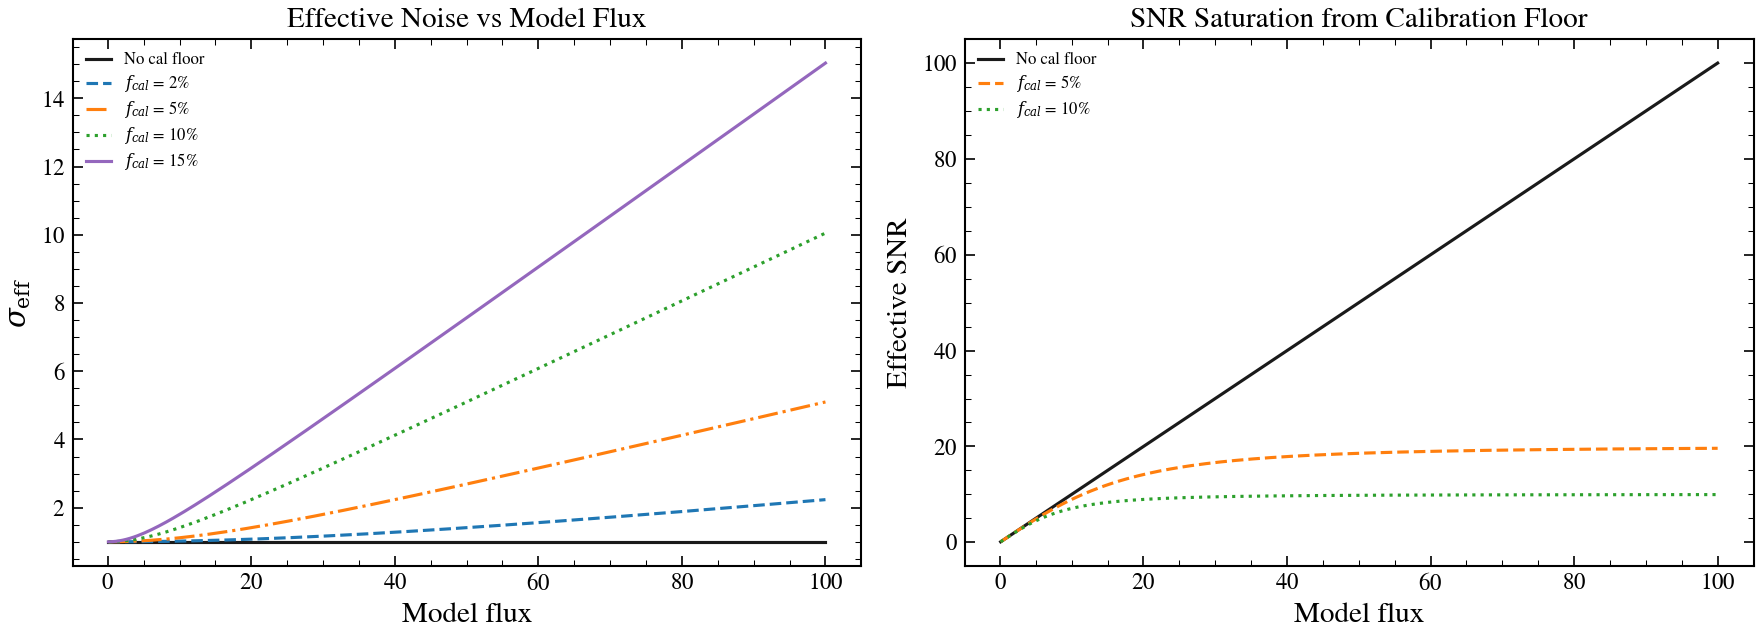

In [2]:
# --- FIGURE 1: Calibration floor effect ---
model_flux = jnp.array([1.0, 5.0, 10.0, 50.0, 100.0])
noise_obs = jnp.array([0.5, 0.5, 0.5, 0.5, 0.5])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: effective noise vs model flux for different f_cal
ax = axes[0]
flux_grid = jnp.linspace(0.1, 100, 200)
noise_fixed = jnp.full_like(flux_grid, 1.0)
for f_cal, color, ls in [
    (0.0, COLORS["truth"], "-"),
    (0.02, COLORS["rt"], "--"),
    (0.05, COLORS["geovi"], "-."),
    (0.10, COLORS["nuts"], ":"),
    (0.15, COLORS["mgvi"], "-"),
]:
    eff = compute_effective_noise(noise_fixed, flux_grid, f_cal)
    ax.plot(
        np.array(flux_grid),
        np.array(eff),
        color=color,
        ls=ls,
        lw=1.5,
        label=f"$f_{{cal}}$ = {f_cal:.0%}" if f_cal > 0 else "No cal floor",
    )
ax.set_xlabel("Model flux")
ax.set_ylabel(r"$\sigma_{\rm eff}$")
ax.set_title("Effective Noise vs Model Flux")
ax.legend(fontsize=8, frameon=False)

# Right: SNR with and without cal floor
ax = axes[1]
for f_cal, color, ls in [
    (0.0, COLORS["truth"], "-"),
    (0.05, COLORS["geovi"], "--"),
    (0.10, COLORS["nuts"], ":"),
]:
    eff = compute_effective_noise(noise_fixed, flux_grid, f_cal)
    snr = flux_grid / eff
    ax.plot(
        np.array(flux_grid),
        np.array(snr),
        color=color,
        ls=ls,
        lw=1.5,
        label=f"$f_{{cal}}$ = {f_cal:.0%}" if f_cal > 0 else "No cal floor",
    )
ax.set_xlabel("Model flux")
ax.set_ylabel("Effective SNR")
ax.set_title("SNR Saturation from Calibration Floor")
ax.legend(fontsize=8, frameon=False)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "06_calibration_floor.png"), bbox_inches="tight")
plt.show()

## 2. Student-t Likelihood

The Student-t distribution has heavier tails than a Gaussian, making it
robust to outliers. It reduces to Gaussian as $\nu \to \infty$.

$$p(d | m, \sigma, \nu) = \frac{\Gamma((\nu+1)/2)}{\Gamma(\nu/2)\sqrt{\pi\nu}\sigma}
\left(1 + \frac{(d-m)^2}{\nu\sigma^2}\right)^{-(\nu+1)/2}$$

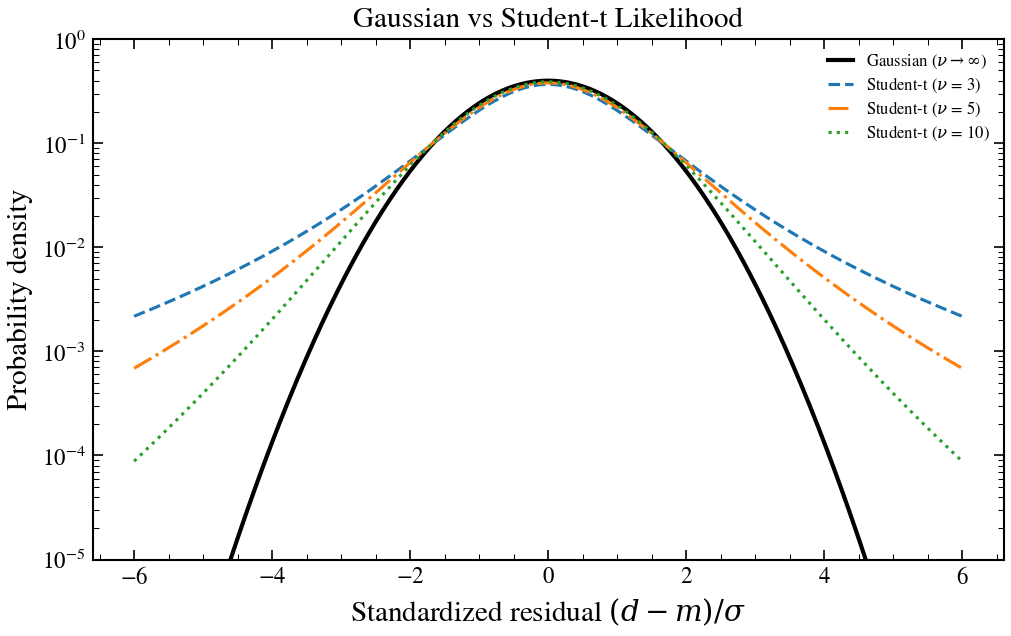

In [3]:
# --- FIGURE 2: Student-t vs Gaussian comparison ---
from scipy.stats import norm, t as student_t

x = np.linspace(-6, 6, 500)
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(x, norm.pdf(x), "k-", lw=2, label=r"Gaussian ($\nu \to \infty$)")
for nu, color, ls in [
    (3, COLORS["rt"], "--"),
    (5, COLORS["geovi"], "-."),
    (10, COLORS["nuts"], ":"),
]:
    ax.plot(
        x, student_t.pdf(x, df=nu), color=color, ls=ls, lw=1.5, label=f"Student-t ($\\nu$ = {nu})"
    )

ax.set_xlabel("Standardized residual $(d - m)/\\sigma$")
ax.set_ylabel("Probability density")
ax.set_title("Gaussian vs Student-t Likelihood")
ax.set_yscale("log")
ax.set_ylim(1e-5, 1)
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "06_student_t.png"), bbox_inches="tight")
plt.show()

## 3. Fitting with Noise Model

We demonstrate fitting with the calibration floor as a free parameter.

In [4]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])

# ParamSpec with noise model
spec_noise = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    noise_frac_cal=Uniform(0.01, 0.2),
)

# ParamSpec without noise model (for comparison)
spec_no_noise = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
)

# Generate mock with 5% systematic floor baked in
model_truth = Model(spec_no_noise, ssp_data, filters=filters)
truth_params = {
    "sfh_tsnorm_log_peak_sfr": 0.8,
    "sfh_tsnorm_peak_lbt_gyr": 4.0,
    "sfh_tsnorm_width_gyr": 2.0,
    "sfh_tsnorm_skew": 0.3,
    "sfh_tsnorm_trunc": 5.0,
    "met_logzsol": -0.2,
    "dust_tau_bc": 0.3,
    "dust_tau_diff": 0.5,
    "dust_slope": -0.7,
    "redshift": 0.1,
}
mock = model_truth.mock(truth_params, snr=30.0, key=jax.random.PRNGKey(42))

# Add 5% systematic scatter
key = jax.random.PRNGKey(99)
sys_scatter = 0.05 * mock.flux_true * jax.random.normal(key, shape=mock.flux_true.shape)
flux_with_sys = mock.flux_obs + sys_scatter

# Fit without noise model
model_no_noise = Model(spec_no_noise, ssp_data, filters=filters)
fitter_no_noise = Fitter(model_no_noise, flux_with_sys, mock.noise)
result_no_noise = fitter_no_noise.run("map", n_steps=500, learning_rate=0.02)

# Fit with noise model
model_noise = Model(spec_noise, ssp_data, filters=filters)
fitter_noise = Fitter(model_noise, flux_with_sys, mock.noise)
result_noise = fitter_noise.run("map", n_steps=500, learning_rate=0.02)

print("Without noise model - final loss:", float(result_no_noise.diagnostics.get("final_loss", 0)))
print("With noise model - final loss:", float(result_noise.diagnostics.get("final_loss", 0)))
if "noise_frac_cal" in result_noise.params:
    print(f"Inferred f_cal: {float(result_noise.params['noise_frac_cal']):.3f} (true: 0.05)")

W0321 13:23:23.352550 14669454 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_3850/3046075588.py:34: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_truth = Model(spec_no_noise, ssp_data, filters=filters)


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_3850/3046075588.py:55: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_no_noise = Model(spec_no_noise, ssp_data, filters=filters)


  Step     0/500: loss = 610.7531
  Step   200/500: loss = 4.2295
  Step   400/500: loss = 3.8683
  Step   499/500: loss = 3.7159
  MAP (ADAM) complete in 0.6s, 500 steps


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_3850/3046075588.py:60: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_noise = Model(spec_noise, ssp_data, filters=filters)


  Step     0/500: loss = 198.1953
  Step   200/500: loss = -318.2841
  Step   400/500: loss = -318.9786
  Step   499/500: loss = -319.4037
  MAP (ADAM) complete in 0.6s, 500 steps
Without noise model - final loss: 3.715903794806552
With noise model - final loss: -319.4037441316327
Inferred f_cal: 0.088 (true: 0.05)


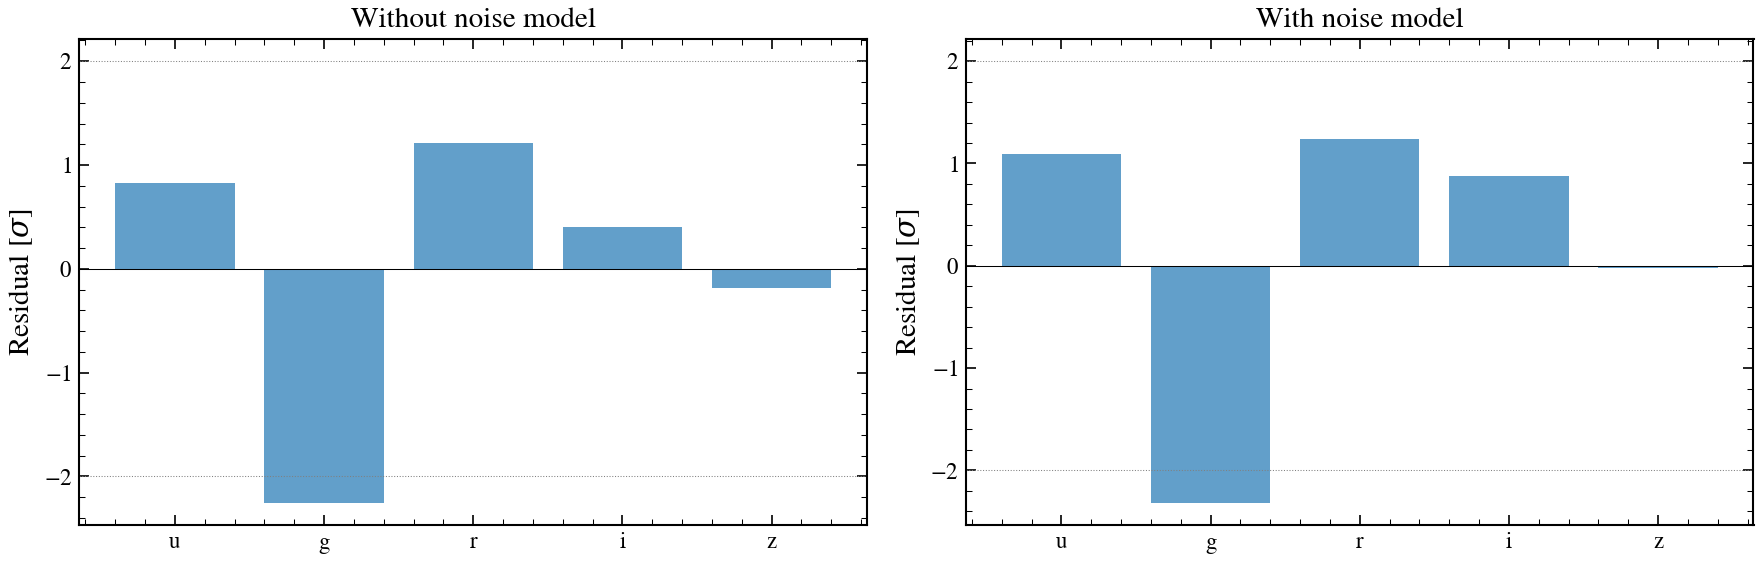

In [5]:
# --- FIGURE 3: Residuals comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
wave_eff = np.array([3551, 4686, 6166, 7480, 8932])

for ax, result, title in [
    (axes[0], result_no_noise, "Without noise model"),
    (axes[1], result_noise, "With noise model"),
]:
    model_for_res = model_no_noise if "noise_frac_cal" not in result.params else model_noise
    pred = model_for_res.predict_photometry(result.params)
    residuals = (np.array(flux_with_sys) - np.array(pred)) / np.array(mock.noise)
    ax.bar(np.arange(5), residuals, color=COLORS["rt"], alpha=0.7)
    ax.axhline(0, color="k", ls="-", lw=0.5)
    ax.axhline(2, color="grey", ls=":", lw=0.5)
    ax.axhline(-2, color="grey", ls=":", lw=0.5)
    ax.set_xticks(np.arange(5))
    ax.set_xticklabels(["u", "g", "r", "i", "z"])
    ax.set_ylabel(r"Residual [$\sigma$]")
    ax.set_title(title)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "06_noise_residuals.png"), bbox_inches="tight")
plt.show()

## 4. Noise Model Comparison Table

| Feature | Gaussian | + Cal floor | + Student-t |
|---------|----------|-------------|-------------|
| Outlier robustness | No | No | Yes |
| Systematic absorption | No | Yes | Partial |
| Extra parameters | 0 | 1 ($f_{\rm cal}$) | 1 ($\nu$) or 2 |
| When to use | Clean data | Most real data | Known outliers |
| NIFTy likelihood | `Gaussian` | `VariableCovGaussian` | Custom |

**Recommendation**: Enable the calibration floor ($f_{\rm cal}$) for all
real data fitting. Use Student-t only when you know there are flux
outliers (e.g., contaminated bands, emission line boosting).

## Summary

Noise modelling is a first-class citizen in tengri following the NIFTy
Information Field Theory philosophy. The calibration floor prevents
over-fitting to systematic residuals and the Student-t likelihood provides
outlier robustness. Both are jointly inferred with physical parameters.